# Pretrain A/B 비교 (비파괴)

`compare_pretrain_ab.py` 가 **호스트 `os.environ` 을 바꾸지 않습니다.**  
각 측정은 `pretrain_bench_core.isolated_env()` 안에서만 env override 를 적용하고, 끝나면 원래 값으로 복구합니다.

- **A (baseline)**: `MMFFRANDOM_FAST`, `PRETRAIN_AMP` 제거 → 기존 PyG `RandomView` 경로.
- **B (optimized)**: `MMFFRANDOM_FAST=1`, `PRETRAIN_AMP=bf16` → `FastRandomMMFFView` + autocast.

출력: `examples/sslgraph/bench/figs/pretrain_ab_<MMDD_HHMM>/`

  - `pretrain_ab_results.json` — wall / stage ms / resource summary 전부
  - `bars_pretrain_ab_*.png` — wall·CPU·XPU·RSS 막대 (QDF 스타일)
  - `bars_pretrain_stages_*.png` — data/views/fwd/bwd 단계 ms
  - `timeseries_cpu_xpu_*.png` — A/B 각각 CPU·XPU 시계열 (0.5s 이동평균)

CPU/XPU 샘플링은 Windows 에서 QDF `QuantumDeepField_molecule/bench/sampler.py` (PDH) 를 동적 로드해 재사용합니다. QDF 트리가 없으면 psutil CPU-only 폴백.

In [1]:
import os
import shlex
import subprocess
import sys
from pathlib import Path

NB_DIR = Path.cwd()
if NB_DIR.name != "bench":
    NB_DIR = Path("examples/sslgraph/bench").resolve()
REPO_ROOT = NB_DIR.parents[2]
PY = Path(sys.executable)

# --- 사용자 조정 -------------------------------------------------
DATASET = "esol"
BATCH_SIZE = 400
WARMUP = 1
EPOCHS = 1
MAX_ITERS = 3  # 빠른 비교; 전체 epoch 측정은 0
INTERVAL = 0.1  # 리소스 샘플 간격 (초)
# -----------------------------------------------------------------

cmd = [
    str(PY), str(NB_DIR / "compare_pretrain_ab.py"),
    "--dataset", DATASET,
    "--batch-size", str(BATCH_SIZE),
    "--warmup", str(WARMUP),
    "--epochs", str(EPOCHS),
    "--max-iters", str(MAX_ITERS),
    "--interval", str(INTERVAL),
]
print(" ".join(shlex.quote(c) for c in cmd))
print("cwd =", REPO_ROOT)

OUT_DIR = None

proc = subprocess.run(cmd, cwd=str(REPO_ROOT), text=True, encoding="utf-8", errors="replace", check=True)

# 가장 최근 출력 디렉터리
fig_root = NB_DIR / "figs"
dirs = sorted([p for p in fig_root.glob("pretrain_ab_*") if p.is_dir()], key=lambda p: p.stat().st_mtime, reverse=True)
OUT_DIR = dirs[0] if dirs else None
print("latest OUT_DIR:", OUT_DIR)

'c:\DGCL\3DGCL\.venv\Scripts\python.exe' 'c:\DGCL\3DGCL\examples\sslgraph\bench\compare_pretrain_ab.py' --dataset esol --batch-size 400 --warmup 1 --epochs 1 --max-iters 3 --interval 0.1
cwd = c:\DGCL\3DGCL
latest OUT_DIR: c:\DGCL\3DGCL\examples\sslgraph\bench\figs\pretrain_ab_0512_1540


OUT_DIR: c:\DGCL\3DGCL\examples\sslgraph\bench\figs\pretrain_ab_0512_1540
timestamp: 0512_1540
A: baseline (PyG views) | wall_s 10.990522700012662
B: optimized (MMFF_FAST + bf16) | wall_s 3.2932633999735117
speedup A/B wall: 3.3372741154263763


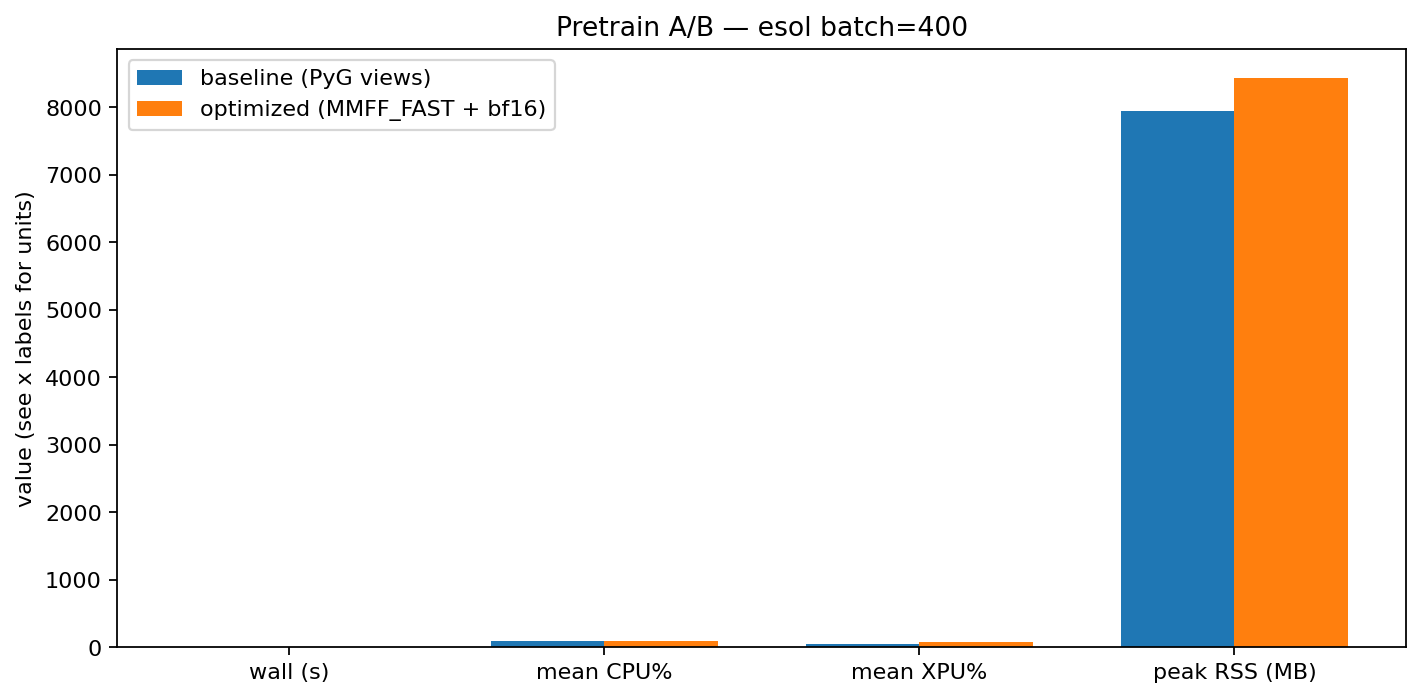

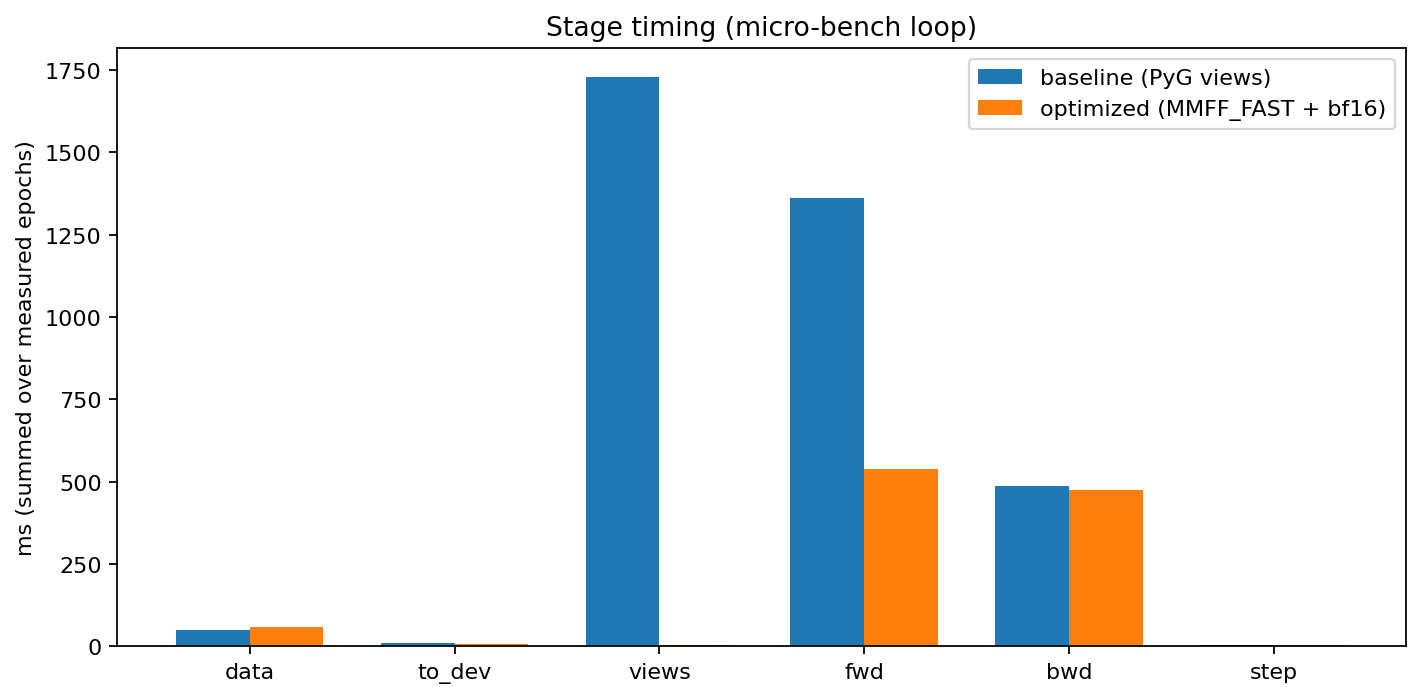

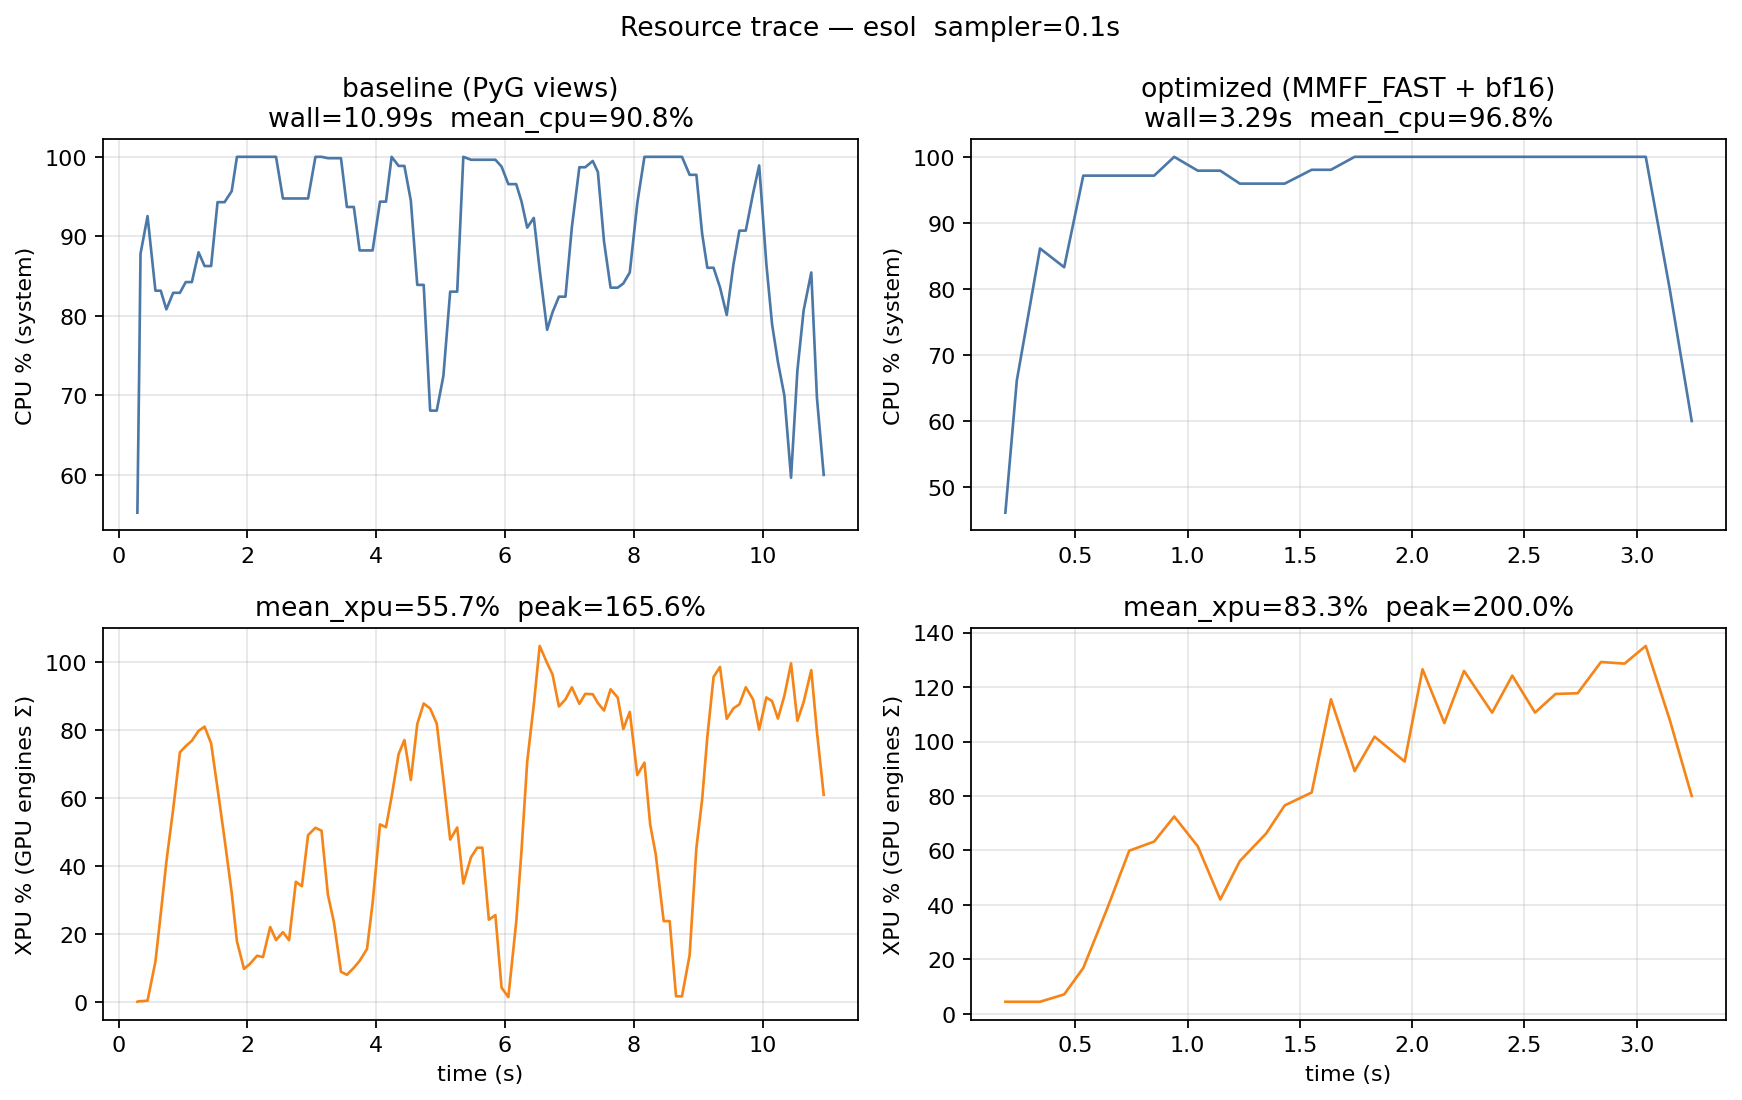

In [2]:
import json
from pathlib import Path
from IPython.display import Image, display

if "NB_DIR" not in dir():
    NB_DIR = Path.cwd()
    if NB_DIR.name != "bench":
        NB_DIR = Path("examples/sslgraph/bench").resolve()

fig_root = NB_DIR / "figs"
if "OUT_DIR" not in dir() or OUT_DIR is None:
    dirs = sorted([p for p in fig_root.glob("pretrain_ab_*") if p.is_dir()], key=lambda p: p.stat().st_mtime, reverse=True)
    OUT_DIR = dirs[0] if dirs else None

if OUT_DIR is None or not OUT_DIR.is_dir():
    raise RuntimeError("OUT_DIR 없음 — 위 셀을 먼저 실행하거나 figs/pretrain_ab_* 가 있는지 확인하세요.")

js = json.loads((OUT_DIR / "pretrain_ab_results.json").read_text(encoding="utf-8"))
ts = js["ts"]
print("OUT_DIR:", OUT_DIR)
print("timestamp:", ts)
print("A:", js["a_label"], "| wall_s", js["summary_a"]["wall_s"])
print("B:", js["b_label"], "| wall_s", js["summary_b"]["wall_s"])
print("speedup A/B wall:", js["summary_a"]["wall_s"] / max(js["summary_b"]["wall_s"], 1e-9))

for name in (
    f"bars_pretrain_ab_{ts}.png",
    f"bars_pretrain_stages_{ts}.png",
    f"timeseries_cpu_xpu_{ts}.png",
):
    p = OUT_DIR / name
    if p.is_file():
        display(Image(filename=str(p)))
    else:
        print("missing:", p)